In [4]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

In [6]:
validation_set = tf.keras.utils.image_dataset_from_directory(
    'plantdataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid',
    labels="inferred",
    label_mode="categorical",
    color_mode="rgb",
    batch_size=1,
    image_size=(64,64),
    shuffle=False,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

class_name = validation_set.class_names
print(class_name)


Found 17572 files belonging to 38 classes.
['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Tw

In [10]:
cnn = tf.keras.models.load_model('train_plant_disease_model.keras')

In [18]:
import os
print(os.listdir('plantdataset'))

['New Plant Diseases Dataset(Augmented)', 'test']


In [20]:
print(os.listdir('plantdataset/New Plant Diseases Dataset(Augmented)'))

['New Plant Diseases Dataset(Augmented)']


In [22]:
print(os.listdir('plantdataset/test'))

['test']


In [24]:
print(os.listdir('plantdataset/test/test'))

['AppleCedarRust1.JPG', 'AppleCedarRust2.JPG', 'AppleCedarRust3.JPG', 'AppleCedarRust4.JPG', 'AppleScab1.JPG', 'AppleScab2.JPG', 'AppleScab3.JPG', 'CornCommonRust1.JPG', 'CornCommonRust2.JPG', 'CornCommonRust3.JPG', 'PotatoEarlyBlight1.JPG', 'PotatoEarlyBlight2.JPG', 'PotatoEarlyBlight3.JPG', 'PotatoEarlyBlight4.JPG', 'PotatoEarlyBlight5.JPG', 'PotatoHealthy1.JPG', 'PotatoHealthy2.JPG', 'TomatoEarlyBlight1.JPG', 'TomatoEarlyBlight2.JPG', 'TomatoEarlyBlight3.JPG', 'TomatoEarlyBlight4.JPG', 'TomatoEarlyBlight5.JPG', 'TomatoEarlyBlight6.JPG', 'TomatoHealthy1.JPG', 'TomatoHealthy2.JPG', 'TomatoHealthy3.JPG', 'TomatoHealthy4.JPG', 'TomatoYellowCurlVirus1.JPG', 'TomatoYellowCurlVirus2.JPG', 'TomatoYellowCurlVirus3.JPG', 'TomatoYellowCurlVirus4.JPG', 'TomatoYellowCurlVirus5.JPG', 'TomatoYellowCurlVirus6.JPG']


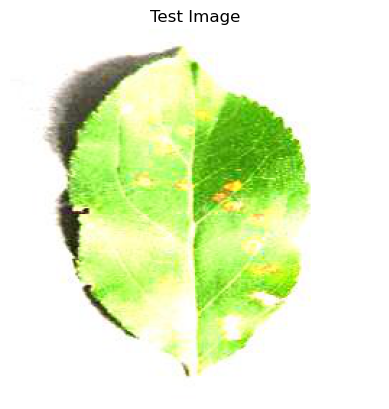

In [32]:
#visualization and performing prediction on single image
#test image visualization
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

image_path = 'plantdataset/test/test/AppleCedarRust1.JPG'

img = image.load_img(image_path, target_size=(512,512))

plt.imshow(img)
plt.title("Test Image")
plt.axis('off')
plt.show()

In [40]:
image = tf.keras.preprocessing.image.load_img(image_path, target_size=(64,64))
input_arr = tf.keras.preprocessing.image.img_to_array(image)
input_arr = np.array([input_arr])

predictions = cnn.predict(input_arr)
result_index = np.argmax(predictions)

print("Prediction:", class_name[result_index])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
Prediction: Apple___Cedar_apple_rust


In [42]:
print(predictions)

[[6.5873697e-05 3.0487894e-07 9.9875534e-01 1.4683341e-06 3.4558216e-05
  1.3410657e-04 3.2239430e-07 2.4908436e-06 1.4917159e-08 1.3466000e-07
  1.7228656e-08 9.8650105e-07 4.3854090e-08 8.8595505e-07 5.4018979e-04
  1.3833413e-04 4.4208787e-06 5.7790777e-07 2.4083008e-06 5.4646847e-05
  7.0445552e-08 1.5038013e-06 1.2867824e-06 2.4176920e-06 4.3919400e-07
  9.8167061e-07 7.6368121e-07 1.0513608e-07 1.1916446e-05 3.7331024e-06
  8.4687548e-05 4.8155908e-07 1.4931192e-04 6.9524231e-07 6.4423818e-07
  9.4980055e-07 4.7114770e-07 2.3393193e-06]]


In [46]:
result_index = np.argmax(predictions)
print(result_index)

2


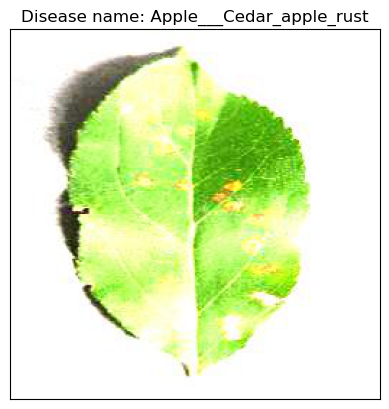

In [52]:
#display the disease prediction
from tensorflow.keras.preprocessing import image

img_display = image.load_img(image_path, target_size=(512,512))

plt.imshow(img_display)   # 🔥 THIS was missing

plt.title(f"Disease name: {model_prediction}")
plt.xticks([])
plt.yticks([])

plt.show()